In [35]:
import os
import cv2
import numpy as np
from numpy.ma.core import indices
from tqdm import tqdm
from ultralytics import YOLO
import time
import torch
import torchvision.transforms as transforms

from mmpose.apis import init_model
from models.vitpose.models.backbone.vit import ViT
from models.vitpose.models.detectors.top_down import TopDown
from models.vitpose.models.head.topdown_heatmap_simple_head import TopdownHeatmapSimpleHead
from models.vitpose.models.head import topdown_heatmap_simple_head
from mmpose.registry import MODELS

from vit_pose import direct_inference

# Configuration

In [36]:
FRAMES_DIR = 'frames_0.5'
FRAMES_UPSCALED_DIR = 'frames_0.5_upscaled'
SKELETON_DIR = 'skeletons_yolo_11_new'
SKELETON_UPSCALED_DIR = 'skeletons_yolo_11_upscaled_2'

YOLO_MODEL_DETECTION = 'models/yolo/yolo11x.pt'
SUPER_RESOLUTION_MODEL_PATH = 'models/super_resolution'
VITPOSE_MODEL_PATH = 'models/vitpose'

# Models
_DETECTION_MODEL = None
_VITPOSE_MODEL = None
_DATASET_INFO = None

# --- Super-resolution setup ---
_SR_NET = None
_SR_SCALE = 4
_SR_PB = os.path.join(SUPER_RESOLUTION_MODEL_PATH, "ESPCN_x4.pb")

# Register components

In [37]:
MODELS.register_module(module=ViT, force=True)
MODELS.register_module(module=TopDown, force=True)
MODELS.register_module(module=TopdownHeatmapSimpleHead, force=True)

models.vitpose.models.head.topdown_heatmap_simple_head.TopdownHeatmapSimpleHead

# Upscaling images

In [38]:
def upscale_img_folder(folder_name):
    # Paths
    input_frames = os.path.join(FRAMES_DIR, folder_name)
    output_frames = os.path.join(FRAMES_UPSCALED_DIR, folder_name)

    if not os.path.exists(input_frames):
        print(f"Input folder not found: {input_frames}")
        return

    print("Step 1: Creating upscaled frames...")
    start_time = time.time()

    os.makedirs(output_frames, exist_ok=True)
    files = sorted([f for f in os.listdir(input_frames) if f.endswith('.jpg')])

    init_super_resolution_model()

    for fname in tqdm(files, desc=f"Upscaling {os.path.basename(input_frames)}"):
        input_path = os.path.join(input_frames, fname)
        output_path = os.path.join(output_frames, fname)

        if os.path.exists(output_path):
            continue

        img = cv2.imread(input_path)
        if img is None:
            continue

        # Apply super-resolution or high-quality upscaling
        upscaled_img = apply_super_resolution(img)

        # Save upscaled image
        cv2.imwrite(output_path, upscaled_img)

    upscale_time = time.time() - start_time
    print(f"Upscaling completed in {upscale_time:.2f} seconds")


def init_super_resolution_model():
    """
    Initialize super-resolution model
    """
    global _SR_NET

    if _SR_NET is not None:
        return _SR_NET

    try:
        # Check if dnn_superres is available
        if hasattr(cv2, 'dnn_superres'):
            sr = cv2.dnn_superres.DnnSuperResImpl_create()
        else:
            print("dnn_superres not available in your OpenCV build")
            return None

        # Load model
        sr.readModel(_SR_PB)
        sr.setModel('espcn', _SR_SCALE)

        # Set backend (CPU for compatibility)
        sr.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
        sr.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)

        print("Super-resolution model initialized successfully")
        _SR_NET = sr
        return sr

    except Exception as e:
        print(f"Failed to initialize super-resolution: {e}")
        return None


def apply_super_resolution(img, target_scale=4):
    """
    Apply super-resolution with guaranteed scale factor
    """
    sr = init_super_resolution_model()
    if sr is None:
        height, width = img.shape[:2]
        return cv2.resize(img, (width * target_scale, height * target_scale), interpolation=cv2.INTER_CUBIC)

    try:
        height, width = img.shape[:2]
        target_height, target_width = height * target_scale, width * target_scale

        # Apply super-resolution
        sr_result = sr.upsample(img)

        # If the SR result isn't exactly the target size, resize to match
        sr_height, sr_width = sr_result.shape[:2]
        if sr_height != target_height or sr_width != target_width:
            sr_result = cv2.resize(sr_result, (target_width, target_height), interpolation=cv2.INTER_LANCZOS4)

        return sr_result

    except Exception as e:
        print(f"Super-resolution failed: {e}")
        height, width = img.shape[:2]
        return cv2.resize(img, (width * target_scale, height * target_scale), interpolation=cv2.INTER_CUBIC)

In [39]:
#upscale_img_folder('002')

# 2 stage detection
yolo model for detecting and vitpose for extracting skeletons

In [40]:
# enhanced_detection_pipeline
def nms_boxes(boxes, iou_threshold):
    x1, y1, x2, y2, scores = boxes.T
    indices = scores.argsort()[::-1]

    keep =[]
    while len(indices) > 0:
        i = indices[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[indices[1:]])
        yy1 = np.maximum(y1[i], y1[indices[1:]])
        xx2 = np.minimum(x2[i], x2[indices[1:]])
        yy2 = np.minimum(y2[i], y2[indices[1:]])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)
        inter = w * h
        area_i = (x2[i] - x1[i]) * (y2[i] - y1[i])
        area_rest = (x2[indices[1:]] - x1[indices[1:]]) * (y2[indices[1:]] - y1[indices[1:]])
        iou = inter / (area_i + area_rest - inter + 1e-6)

        indices = indices[1:][iou < iou_threshold]

    return boxes[keep]


def yolo_detection(img, model):
    all_boxes = []

    # Shadow suppression
    rgb_planes = cv2.split(img)
    result_planes = []
    result_norm_planes = []

    for plane in rgb_planes:
        dilated_img = cv2.dilate(plane, np.ones((4,4), np.uint8))
        bg_img = cv2.medianBlur(dilated_img, 21)
        diff_img = 255 - cv2.absdiff(plane, bg_img)
        norm_img = cv2.normalize(diff_img,None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8UC1)
        result_planes.append(diff_img)
        result_norm_planes.append(norm_img)

    result_norm = cv2.merge(result_norm_planes)

    enhanced_imgs = [img]


    # CLAHE enhancement on upscaled image
    lab = cv2.cvtColor(result_norm, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    enhanced_img = cv2.merge((l, a, b))
    enhanced_img = cv2.cvtColor(enhanced_img, cv2.COLOR_LAB2BGR)
    enhanced_imgs.append(enhanced_img)

    # Histogram equalization
    yuv = cv2.cvtColor(result_norm, cv2.COLOR_BGR2YUV)
    yuv[:, :, 0] = cv2.equalizeHist(yuv[:, :, 0])
    enhanced2 = cv2.cvtColor(yuv, cv2.COLOR_YUV2BGR)
    enhanced_imgs.append(enhanced2)

    # Gamma correction
    gamma = 0.8
    enhanced3 = np.power(result_norm / 255.0, gamma) * 255.0
    enhanced3 = enhanced3.astype(np.uint8)
    enhanced_imgs.append(enhanced3)

    # Yolo configuration
    configs = [
        {'conf': 0.65, 'imgsz': 1280, 'iou': 0.6},
        {'conf': 0.60, 'imgsz': 1024, 'iou': 0.6},
        {'conf': 0.60, 'imgsz': 1536, 'iou': 0.6},
        {'conf': 0.55, 'imgsz': 1792, 'iou': 0.7},
        {'conf': 0.4, 'imgsz': 2048, 'iou': 0.6},
    ]

    for img_idx, enhanced_img in enumerate(enhanced_imgs):
        if img_idx == 0:
            config_indices = [0, 2]
        elif img_idx == 1:  # CLAHE
            config_indices = [1, 3]
        elif img_idx == 2:  # Histogram equalized
            config_indices = [0, 4]
        else:  # Gamma corrected
            config_indices = [1]

        for config_idx in config_indices:
            try:
                res = model(enhanced_img, verbose=False, **configs[config_idx])
                if res[0].boxes is not None:
                    boxes = res[0].boxes.xyxy.cpu().numpy()
                    confs = res[0].boxes.conf.cpu().numpy()
                    all_boxes.append(np.column_stack([boxes, confs]))
            except Exception as e:
                print(f"Detection failed: {e}")
                continue

    if not all_boxes:
        return np.array([])

    combined_boxes = np.vstack(all_boxes)
    #combined_boxes = nms_boxes(combined_boxes, iou_threshold=0.4)

    return combined_boxes


# process_upscaled_folder
def first_stage_detection(frames_dir, skeleton_dir, model):
    """
    Yolo person detection
    """
    os.makedirs(skeleton_dir, exist_ok=True)
    files = sorted(f for f in os.listdir(frames_dir) if f.endswith('.jpg'))
    all_boxes = []


    for fname in tqdm(files, desc=f"Detecting skeletons in {os.path.basename(frames_dir)}"):
        path = os.path.join(frames_dir, fname)
        img = cv2.imread(path)
        if img is None:
            continue

        boxes = yolo_detection(img, model)
        all_boxes.append(boxes)

## Second stage VitPose

In [41]:
from mmpose.apis import inference_topdown
from visualization_helper import visualize_detections


class VitPoseExtractor:
    def __init__(self, config_file, checkpoint_file, device='cuda'):
        self.model = init_model(config_file, checkpoint_file, device=device)

    def extract_keypoints(self, img, boxes, visualize=False, save_path=None):
        """Extract keypoints from image using detected bounding boxes"""
        if boxes is None or len(boxes) == 0:
            return np.array([])

        skeletons = []
        boxes_without_score = boxes[:, :4].astype(np.float32)

        # Visualize bounding boxes before ViTPose extraction
        if visualize:
            visualize_detections(
                img, boxes, skeletons=None,
                title="YOLO Detections (Stage 1)",
                save_path=save_path.replace('.jpg', '_bboxes.jpg') if save_path else None,
                show=True
            )

        pose_results = inference_topdown(self.model, img, boxes_without_score, "xyxy")

        for result in pose_results:
            if hasattr(result, 'pred_instances'):
                keypoints = result.pred_instances.keypoints[0]
                scores = result.pred_instances.keypoint_scores[0]
                skeleton = np.concatenate([keypoints, scores[:, None]], axis=1)
                skeletons.append(skeleton)

        skeletons_array = np.array(skeletons) if skeletons else np.array([])

        # Visualize with skeletons after ViTPose extraction
        if visualize and len(skeletons_array) > 0:
            visualize_detections(
                img, boxes, skeletons=skeletons_array,
                title="ViTPose Results (Stage 2)",
                save_path=save_path,
                show=True
            )

        return skeletons_array


In [42]:
  def two_stage_skeleton_extraction(frames_dir, skeleton_dir, yolo_model_path, visualize_first_n=3):
    """
    Args:
        visualize_first_n: number of frames to visualize (default: 3)
    """
    os.makedirs(skeleton_dir, exist_ok=True)
    vis_dir = os.path.join(skeleton_dir, 'visualizations')
    os.makedirs(vis_dir, exist_ok=True)

    files = sorted(f for f in os.listdir(frames_dir) if f.endswith('.jpg'))

    yolo_model = YOLO(yolo_model_path)
    config_file = 'models/vitpose/configs/ViTPose_huge_crowdpose_256x192_without_training_v3.py'
    checkpoint_file = 'models/vitpose/vitpose-h-multi-crowdpose.pth'
    vitpose_extractor = VitPoseExtractor(config_file, checkpoint_file, device='cuda')

    total_detections = 0

    for idx, fname in enumerate(tqdm(files, desc=f"Processing {os.path.basename(frames_dir)}")):
        path = os.path.join(frames_dir, fname)
        img = cv2.imread(path)
        if img is None:
            continue

        # Stage 1: YOLO Detection
        bounding_boxes = yolo_detection(img, yolo_model)

        if len(bounding_boxes) == 0:
            skeleton_path = os.path.join(skeleton_dir, fname.replace('.jpg', '.npy'))
            np.save(skeleton_path, np.array([]))
            continue

        # Stage 2: ViTPose - visualize first N frames
        should_visualize = idx < visualize_first_n
        vis_save_path = os.path.join(vis_dir, fname) if should_visualize else None

        skeletons = vitpose_extractor.extract_keypoints(
            img, bounding_boxes,
            visualize=should_visualize,
            save_path=vis_save_path
        )

        skeleton_path = os.path.join(skeleton_dir, fname.replace('.jpg', '.npy'))
        np.save(skeleton_path, skeletons)

        total_detections += len(skeletons)
        print(f"Frame {fname}: Found {len(skeletons)} skeletons (from {len(bounding_boxes)} detections)")

    print(f"\nTotal skeletons extracted: {total_detections}")
    print(f"Visualizations saved to: {vis_dir}")

In [43]:
def run_pipeline():
    # Run the complete pipeline
    two_stage_skeleton_extraction(
        'frames_0.5_upscaled/002',
        SKELETON_UPSCALED_DIR,
        YOLO_MODEL_DETECTION
    )

Loads checkpoint by local backend from path: models/vitpose/vitpose-h-multi-crowdpose.pth


Processing 002:   0%|          | 0/6 [00:00<?, ?it/s]

Saved visualization to: skeletons_yolo_11_upscaled_2\visualizations\001_0076_bboxes.jpg


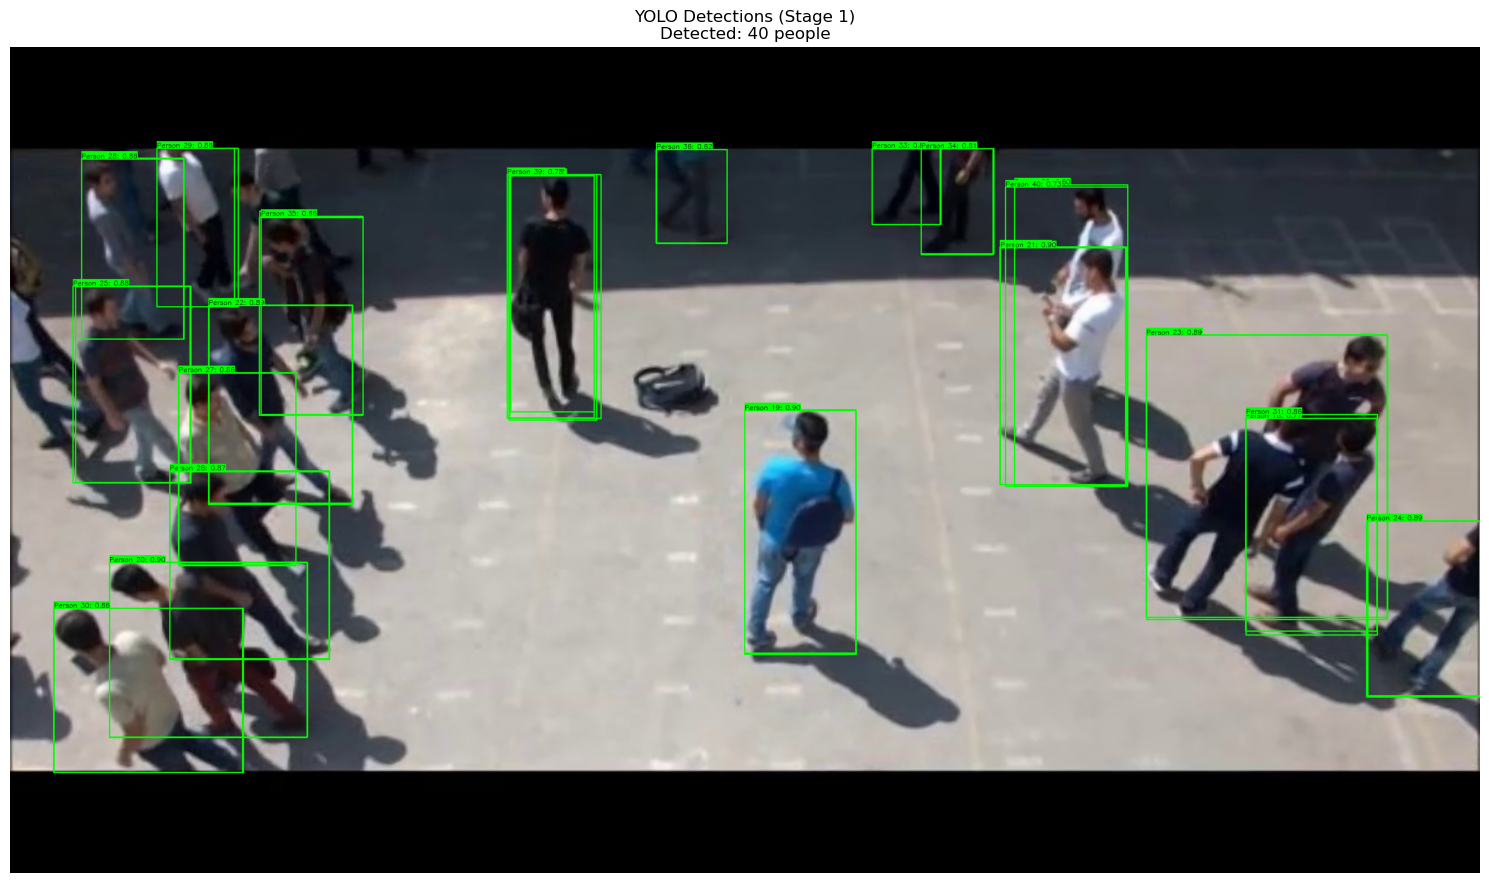

Saved visualization to: skeletons_yolo_11_upscaled_2\visualizations\001_0076.jpg


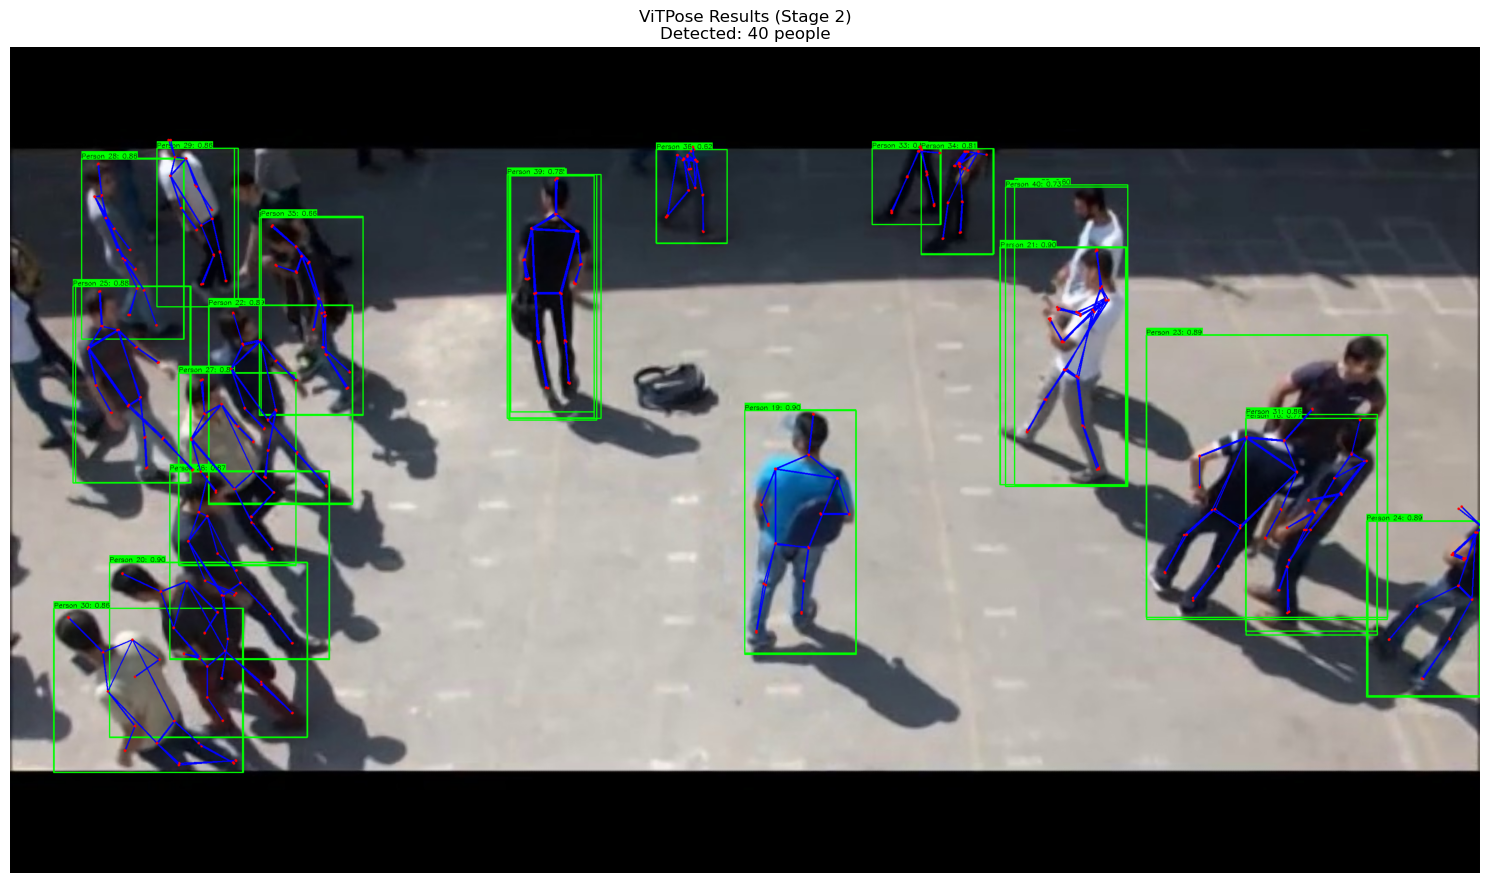

Processing 002:  17%|█▋        | 1/6 [00:04<00:24,  4.93s/it]

Frame 001_0076.jpg: Found 40 skeletons (from 40 detections)
Saved visualization to: skeletons_yolo_11_upscaled_2\visualizations\002_0000_bboxes.jpg


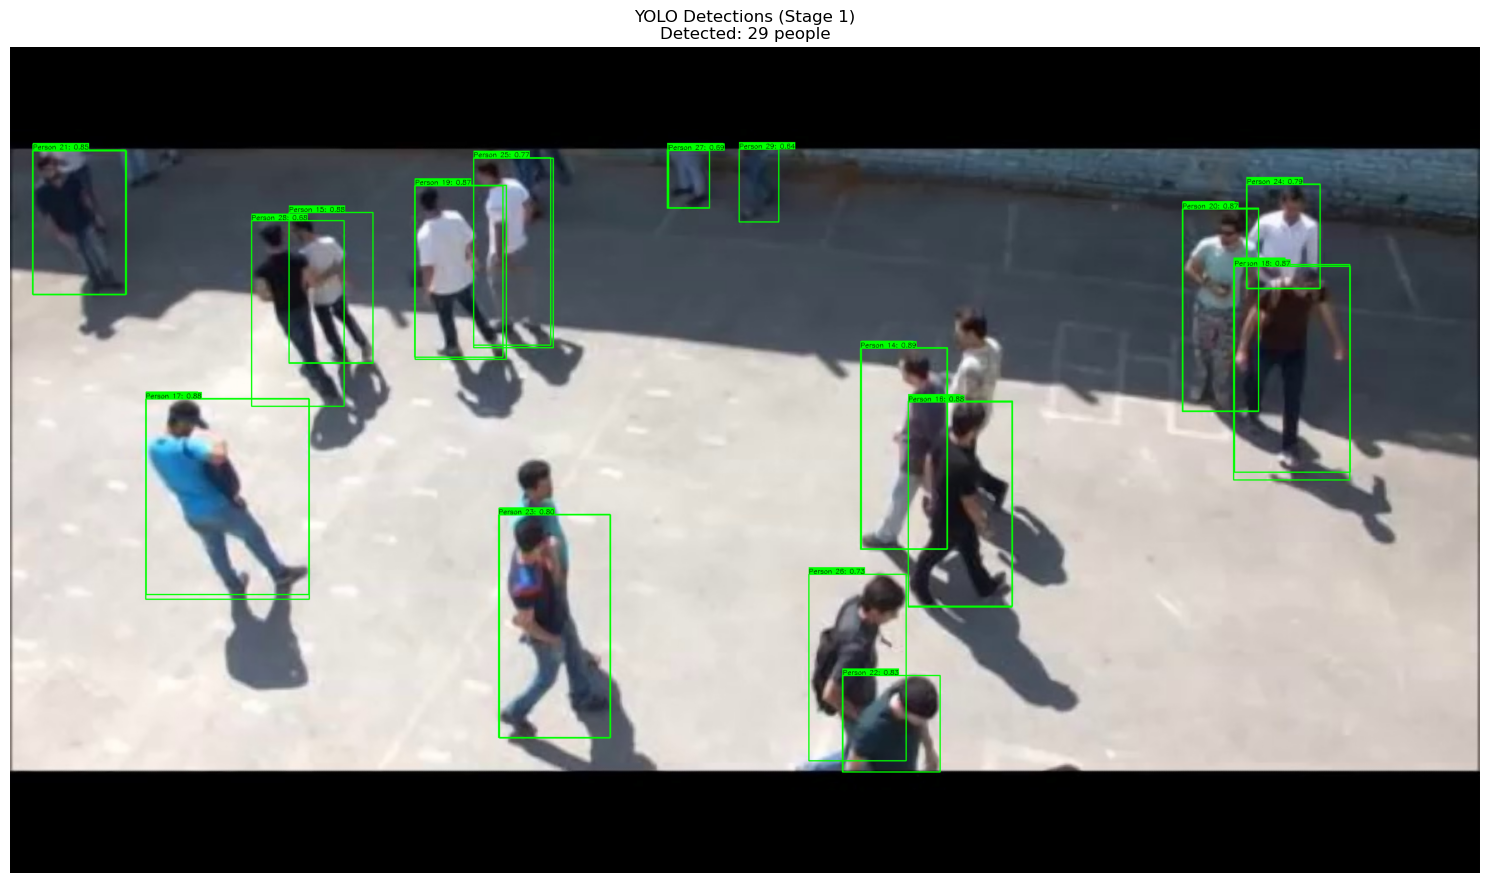

Processing 002:  17%|█▋        | 1/6 [00:07<00:37,  7.40s/it]

Saved visualization to: skeletons_yolo_11_upscaled_2\visualizations\002_0000.jpg


KeyboardInterrupt: 

In [44]:
run_pipeline()